# 07 — Cooperative Map Merging (Trust-Weighted)

`OccupancyMapMerger` (ADR 0010) fuses per-peer lidar fragments into a single occupancy grid. Each beam casts a ray; cells along the ray accumulate **free-vote** weight; the endpoint accumulates **occupied-vote** weight. A cell is marked occupied iff `occ > free`.

The trust integration is the load-bearing knob: `peer_weights[agent_id]` scales every vote from that peer. A liar with low rep contributes proportionally less; honest peers' geometry survives.

**Audited by:** `tests/eval/test_map_convergence.py` (US-011 honest, US-012 adversarial).

## Operator question

**What if a drone lies about what's on the ground, not just about
where it is?**

Trust math is operationally useless if it doesn't reach the operator's
common operating picture. This notebook is where the trust scalar
becomes a *map filter*: free-vote and occupied-vote weights per cell
multiplied by the reporter's reputation at report time. A compromised
drone that lies about contacts (plants phantoms, hides real items,
relocates the friendly FOB) sees its contributions weighted toward
zero as Tier 1 collapses its reputation. Redundancy from honest peers
surfaces the truth.

In the React Workshop Console, Lesson 08 (`cop_corruption_full`) is
the operational demo — A0 plants two phantoms, hides two real items,
and inflates inter-drone range all simultaneously. The trust-weighted
COP filter derived in this notebook is what makes the rail's defense
visible.


In [1]:
%matplotlib inline
import json
import os
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(_root)

from specter.sim.scenario import load_scenario
from specter.sim.sensors import lidar_scan
from specter.slam import OccupancyMapMerger, ScanMatchSlam, encode_fragment
from specter.types import Pose
from specter.viz.notebook import merge_three_panel, merge_side_by_side

## Intuition: build honest fragments, merge, see the three layers

We collect fragments for 80 ticks across 4 honest agents in `four_corners.yaml`, then merge once via `merge_with_votes()` to expose the underlying free/occupied grids that drive the binary decision.

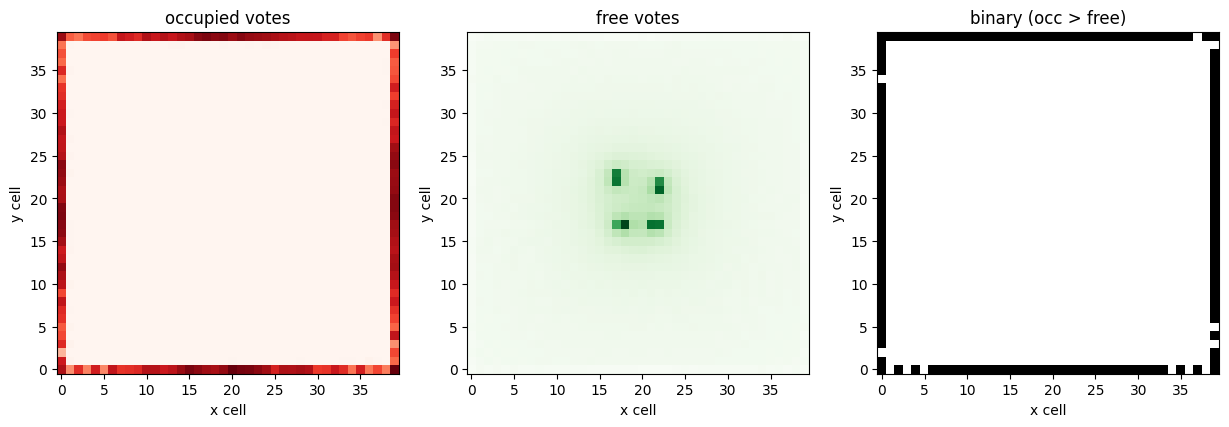

In [2]:
RES = 0.2
N_BEAMS = 120
N_TICKS = 80  # short variant for laptop budget; full eval runs 200

def collect_honest(n_ticks=N_TICKS):
    sim, _ = load_scenario('scenarios/four_corners.yaml')
    slam = {
        a.id: ScanMatchSlam(agent_id=a.id, init_pose=Pose(a.x, a.y, a.theta, 0.0), dt=sim.dt, init_velocity=(a.vx, a.vy))
        for a in sim.agents
    }
    fragments = []
    for _ in range(n_ticks):
        tick = sim.tick()
        for a in tick.agents:
            scans = list(lidar_scan(a, sim.world, sim.rng, sim.t, n_beams=N_BEAMS))
            slam[a.id].update(scans, tick.imu[a.id])
            fragments.append(encode_fragment(a.id, slam[a.id].pose(), scans))
    return fragments, sim.world

fragments, world = collect_honest()
merger = OccupancyMapMerger(world.width, world.height, resolution_m=RES)
binary, occ, free = merger.merge_with_votes(fragments)
cells = json.loads(binary)['cells']
fig = merge_three_panel(occ, free, cells)

## Claim: trust-weighted fusion holds; uniform weights collapse

Inject one liar publishing fragments computed against `+2 m`-offset walls. Compare two merges: with `peer_weights={liar: 0.1}` (trust-weighted, the engine's posture) vs. uniform weights (every peer counts equally — the broken case).

From `tests/eval/test_map_convergence.py`:

| Configuration | Recall | Precision |
|---|---|---|
| Honest 4-peer | ≥90% | ≥95% |
| 3 honest + 1 liar, `peer_weights={liar:0.1}` | ≥85% | ≥90% |
| Same input, **uniform weights** | <60% | <70% |

The visual below shows the binary outputs side-by-side.

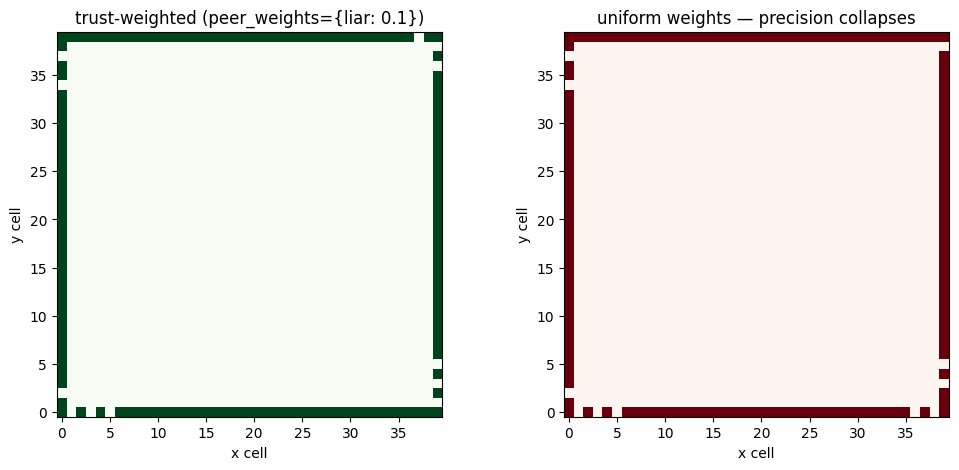

In [3]:
def collect_with_liar(offset_m=2.0, n_ticks=N_TICKS):
    sim, _ = load_scenario('scenarios/four_corners.yaml')
    slam = {
        a.id: ScanMatchSlam(agent_id=a.id, init_pose=Pose(a.x, a.y, a.theta, 0.0), dt=sim.dt, init_velocity=(a.vx, a.vy))
        for a in sim.agents
    }
    liar = sim.agents[0].id
    fragments = []
    # Build a parallel world with offset walls — used to source the liar's scans.
    from specter.sim.world import Wall, box_world
    fake_walls = tuple(
        Wall(w.x1 + offset_m, w.y1, w.x2 + offset_m, w.y2) for w in sim.world.walls
    )
    fake_world = box_world(sim.world.width, sim.world.height, *fake_walls)
    for _ in range(n_ticks):
        tick = sim.tick()
        for a in tick.agents:
            scans = list(lidar_scan(a, sim.world, sim.rng, sim.t, n_beams=N_BEAMS))
            slam[a.id].update(scans, tick.imu[a.id])
            if a.id == liar:
                fake_scans = list(lidar_scan(a, fake_world, sim.rng, sim.t, n_beams=N_BEAMS))
                fragments.append(encode_fragment(a.id, slam[a.id].pose(), fake_scans))
            else:
                fragments.append(encode_fragment(a.id, slam[a.id].pose(), scans))
    return fragments, sim.world, liar

frag_adv, world, liar_id = collect_with_liar()
weighted = OccupancyMapMerger(
    world.width, world.height, resolution_m=RES, peer_weights={liar_id: 0.1},
)
uniform = OccupancyMapMerger(world.width, world.height, resolution_m=RES)
weighted_cells = json.loads(weighted.merge(frag_adv))['cells']
uniform_cells = json.loads(uniform.merge(frag_adv))['cells']
fig = merge_side_by_side(weighted_cells, uniform_cells)

## Claim: trust-weighted COP defeats composite map-layer attacks

ADR 0019 + Coverage Parity Wave 3. The Common Operating Picture is the
operator-facing aggregation of every reporter's contact stream, weighted
by reporter reputation. Compromised reporters can inject phantoms or
suppress real items; once Tier 1 reciprocal disagreement (range_lie)
collapses their reputation below `COP_TRUST_THRESHOLD = 0.5`, their
contributions stop affecting the COP.

**`cop_corruption_full`** is the composite stress test — alpha plants two
phantoms (`phantom-uxo-1`, `phantom-fob-1`) AND hides two real items
(`uxo-bravo`, `fob-stalwart`) AND lies on inter-drone range, all
simultaneously. Honest peers within sensor radius keep reporting the
real items; alpha's phantoms become single-reporter entries with the
attacker's collapsed reputation as their only weight. The COP filter
drops the phantoms and surfaces the real items via redundancy.

Claim source: `tests/eval/test_attack_battery.py::test_cop_corruption_full_composite_defeated`.


In [4]:
import os, sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from tests.eval.runner import run_scenario
from tests.eval import scenarios

result = run_scenario(scenarios.cop_corruption_full())
print('Attacker reputation (avg honest view):',
      f'{sum(result.final_rep[v]["alpha"] for v in result.final_rep if v != "alpha") / 3:.3f}')
print()
print('COP survival vs ground truth:')
print(f'  {"contact_id":<18s}  surfaced?  reporters')
expected_real    = ['uxo-bravo', 'fob-stalwart']
expected_phantom = ['phantom-uxo-1', 'phantom-fob-1']
for cid in expected_real + expected_phantom:
    entry = result.cop.get(cid)
    if entry is None:
        flag = 'dropped'
        rep = '-'
    else:
        flag = f'{entry.weight:.3f}'
        rep = ','.join(entry.reporters)
    expected = 'real' if cid in expected_real else 'phantom'
    print(f'  {cid:<18s}  ({expected:7s})  {flag:>8s}   {rep}')


Attacker reputation (avg honest view): 0.252

COP survival vs ground truth:
  contact_id          surfaced?  reporters
  uxo-bravo           (real   )     0.991   bravo,charlie,delta
  fob-stalwart        (real   )     0.991   bravo,charlie,delta
  phantom-uxo-1       (phantom)   dropped   -
  phantom-fob-1       (phantom)   dropped   -


## Limit

**Pose correction is out of scope** for the map merger (per ADR 0010). Loop closure detection ships (`detect_loop_closure(scan, pose, merged_map)`); pose-graph optimization is the integrator's responsibility — usually outsourced to a real SLAM stack like Cartographer / SLAM Toolbox in the hardware port.

The merger consumes the trust scalar but doesn't decide it — `peer_weights` comes from outside (e.g., `evaluator.reputation(peer_id)`). If the trust engine is wrong, the merger is wrong.